## Fine‑tuning of clasification model based on transformers: 
### distilbert-base-uncased (DistilBERT)

In [12]:
using_colab = False

In [13]:
# Check if running in Colab and setup paths
import os
if using_colab:
    import gdown
    url = "https://drive.google.com/uc?id=1T1gBrg3aohHl2XV0deNPXhD7OzNkrcJT"
    DATASET_PATH = "MTS-Dialog-TrainingSet.csv"
    gdown.download(url, DATASET_PATH, quiet=False)
    
else:
    using_colab = False
    DATASET_PATH = "../../dataset/MTS-Dialog-TrainingSet.csv"

print(f"Running in Colab: {using_colab}")
print(f"Dataset path: {DATASET_PATH}")

Running in Colab: False
Dataset path: ../../dataset/MTS-Dialog-TrainingSet.csv


In [ ]:
import re
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset
import numpy as np
import pandas as pd
from transformers import DistilBertTokenizer

In [ ]:
# dataset load
df = pd.read_csv(DATASET_PATH)

In [ ]:
# BERT preprocessing
def normalize_for_bert(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s))
    s = re.sub(r'\b(Doctor|Doctor_2|Patient|Guest_family(_\d)?|Guest_clinician)[:\-]\s*', '', s, flags=re.I)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['text_for_bert'] = df['dialogue'].apply(normalize_for_bert)


X = df['text_for_bert']
y = df['section_header']

# Encode 
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

In [ ]:
# CLEAN GPU MEMORY FROM PREVIOUS RUNS
import torch
import gc

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleared. Reloading model for frozen weights training...")

Memory cleared. Reloading model for frozen weights training...


In [ ]:
# tokenizar and model load
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model_name = "distilbert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_),
    problem_type="single_label_classification"
)

# tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=512
    )

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
# datasets
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

Map: 100%|██████████| 241/241 [00:00<00:00, 761.58 examples/s]


In [ ]:
# evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

In [ ]:
# training configuration
training_args = TrainingArguments(
    output_dir='./results_distilbert',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    num_train_epochs=50,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir='./logs',
    logging_steps=10,
    seed=42,
    fp16=True,
    gradient_accumulation_steps=2,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [22]:
if using_colab:   
    import os
    import wandb

    # in order to print results using colab API key for wandb is needed as local file usage as .env files or datasets are not well built for the moment
    # if someone else is running the notebook, dont commit your key,make sure to remove it before pushing to the repo repo 
    os.environ["WANDB_API_KEY"] = ""

    wandb.login()

In [ ]:
# Fine-tune FULL MODEL
print("="*60)
print("TRAINING 1: FULL FINE-TUNE")
print("="*60)
trainer.train()

# Evaluación
results = trainer.evaluate()
print(results)

# Save results
results_full_finetune = results.copy()

TRAINING 1: FULL FINE-TUNE


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.764700,1.563227,0.618257,0.227296
2,1.206700,1.077779,0.763485,0.338936
3,0.820400,0.872766,0.796680,0.384146
4,0.639700,0.813004,0.767635,0.358908
5,0.569400,0.755660,0.817427,0.439103
6,0.301400,0.704645,0.817427,0.500975
7,0.249300,0.744324,0.825726,0.567869
8,0.114900,0.739590,0.842324,0.595193
9,0.036600,0.762167,0.838174,0.640059
10,0.083700,0.827049,0.846473,0.588916


{'eval_loss': 0.7621673941612244, 'eval_accuracy': 0.8381742738589212, 'eval_f1_macro': 0.6400589674278133, 'eval_runtime': 0.8894, 'eval_samples_per_second': 270.964, 'eval_steps_per_second': 34.854, 'epoch': 11.0}


In [24]:
# CLEAN MEMORY AND RESET MODEL FOR FAIR COMPARISON
import torch
import gc

# Clear GPU memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleared. Reloading model for frozen weights training...")

# RELOAD MODEL AND RETRAIN WITH FROZEN WEIGHTS
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_),
    problem_type="single_label_classification"
)

# FREEZE BASE MODEL ENCODER WEIGHTS (before training)
for param in model_frozen.distilbert.parameters(): 
    param.requires_grad = False

print("Base model weights frozen")


Memory cleared. Reloading model for frozen weights training...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Base model weights frozen


In [25]:
# CREATE NEW TRAINER WITH FROZEN MODEL
training_args_frozen = TrainingArguments(
    output_dir='./results_distilbert_frozen',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    num_train_epochs=50,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir='./logs_frozen',
    logging_steps=10,
    seed=42,
    fp16=True,
    gradient_accumulation_steps=2,
)

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_frozen,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Train with frozen weights
print("="*60)
print("TRAINING 2: FROZEN WEIGHTS FINE-TUNE")
print("="*60)
trainer_frozen.train()

# Evaluation
results_frozen_weights = trainer_frozen.evaluate()
print(results_frozen_weights)


TRAINING 2: FROZEN WEIGHTS FINE-TUNE


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.589100,2.458656,0.290456,0.025009
2,2.146100,2.186639,0.290456,0.025009
3,2.157900,2.091483,0.390041,0.057484
4,2.087200,2.031708,0.435685,0.064193
5,2.015600,1.981782,0.468880,0.067986
6,1.836700,1.937998,0.460581,0.067141
7,2.105400,1.900801,0.443983,0.064322


{'eval_loss': 1.9817816019058228, 'eval_accuracy': 0.46887966804979253, 'eval_f1_macro': 0.06798607293384644, 'eval_runtime': 0.92, 'eval_samples_per_second': 261.967, 'eval_steps_per_second': 33.697, 'epoch': 7.0}


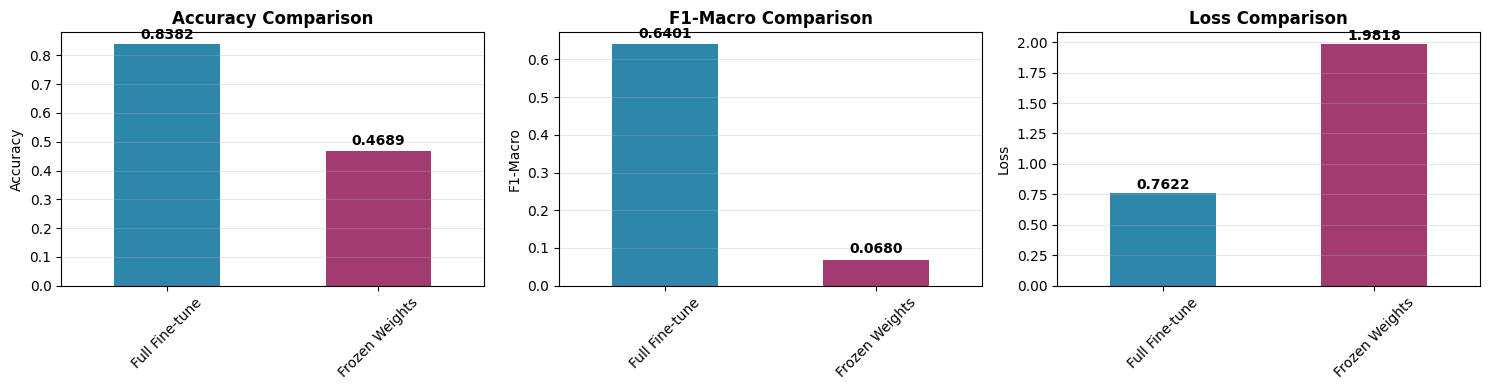


RESULTS COMPARISON - FAIR TEST
                accuracy  f1_macro    loss
Full Fine-tune    0.8382    0.6401  0.7622
Frozen Weights    0.4689    0.0680  1.9818

ANALYSIS:
Accuracy difference (Full - Frozen): +0.3693
F1-Macro difference (Full - Frozen): +0.5721


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for comparison - use the clean results
comparison_data = {
    'Full Fine-tune': {
        'accuracy': results_full_finetune.get('eval_accuracy', 0),
        'f1_macro': results_full_finetune.get('eval_f1_macro', 0),
        'loss': results_full_finetune.get('eval_loss', 0)
    },
    'Frozen Weights': {
        'accuracy': results_frozen_weights.get('eval_accuracy', 0),
        'f1_macro': results_frozen_weights.get('eval_f1_macro', 0),
        'loss': results_frozen_weights.get('eval_loss', 0)
    }
}

# Create comparison dataframe
df_comparison = pd.DataFrame(comparison_data).T

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy comparison
ax1 = axes[0]
df_comparison['accuracy'].plot(kind='bar', ax=ax1, color=['#2E86AB', '#A23B72'])
ax1.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_comparison['accuracy']):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# F1-Macro comparison
ax2 = axes[1]
df_comparison['f1_macro'].plot(kind='bar', ax=ax2, color=['#2E86AB', '#A23B72'])
ax2.set_title('F1-Macro Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1-Macro')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_comparison['f1_macro']):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Loss comparison
ax3 = axes[2]
df_comparison['loss'].plot(kind='bar', ax=ax3, color=['#2E86AB', '#A23B72'])
ax3.set_title('Loss Comparison', fontsize=12, fontweight='bold')
ax3.set_ylabel('Loss')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_comparison['loss']):
    ax3.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print comparison table
print("\n" + "="*60)
print("RESULTS COMPARISON - FAIR TEST")
print("="*60)
print(df_comparison.round(4))
print("="*60)

# Analysis
print("\nANALYSIS:")
accuracy_diff = df_comparison.loc['Full Fine-tune', 'accuracy'] - df_comparison.loc['Frozen Weights', 'accuracy']
f1_diff = df_comparison.loc['Full Fine-tune', 'f1_macro'] - df_comparison.loc['Frozen Weights', 'f1_macro']
print(f"Accuracy difference (Full - Frozen): {accuracy_diff:+.4f}")
print(f"F1-Macro difference (Full - Frozen): {f1_diff:+.4f}")


MODELS PERSISTENCY

In [ ]:
if using_colab:
    # As mentioned before, Colab requires specific handling local files management, if needed, you can mount
    # on personal drive and save it there.
    print("Using colab virtual hardware - model persistency not implemented")

else:
    print("Running locally, model persistency implemented")
    # Guardar modelo
    tokenizer.save_pretrained('./finetuned_distilbert')
    model.save_pretrained('./finetuned_distilbert')
    model_frozen.save_pretrained('./finetuned_distilbert')


    # Guardar encoder de labels
    import pickle
    with open('./finetuned_distilbert/label_encoder.pkl', 'wb') as f:
        pickle.dump(le, f)

Running locally, model persistency implemented


INFERENCE VALIDATION 

In [28]:
# Check if running in Colab and setup paths
import os
if using_colab:
    import gdown
    url = "https://drive.google.com/file/d/1L-Fz5jlc9g1G43jwg-l6Ib23D23Mmxgj/view?usp=sharing"
    DATASET_PATH_2 = "MTS-Dialog-ValidationSet.csv"
    gdown.download(url, DATASET_PATH_2, quiet=False)
    
else:
    using_colab = False
    DATASET_PATH_2 = "../../dataset/MTS-Dialog-ValidationSet.csv"

print(f"Running in Colab: {using_colab}")
print(f"Dataset path: {DATASET_PATH}")

Running in Colab: False
Dataset path: ../../dataset/MTS-Dialog-TrainingSet.csv


FULLY FINETUNED MODEL INFERENCE TEST

In [ ]:
import pandas as pd
from transformers import pipeline
import re, unicodedata

def normalize_for_bert(s):
    s = unicodedata.normalize("NFKC", str(s))
    s = re.sub(r'\b(Doctor|Doctor_2|Patient|Guest_family(_\d)?|Guest_clinician)[:\-]\s*', '', s, flags=re.I)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# Load label encoder and model

clf = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0  # -1 for CPU, (but use the Colab extension we mentioned before if no GPU available)
)

# Load the validation sample
df_val = pd.read_csv(DATASET_PATH_2)

# Predict First Dialogue
text = normalize_for_bert(df_val.loc[0, "dialogue"])  # first row from validation set
out = clf(text)[0]
pred_label = le.inverse_transform([int(out['label'].split('_')[-1])])[0]
print(f"Predicted: {pred_label} | Confidence: {out['score']:.3f}")

# Predict Second Dialogue
text = normalize_for_bert(df_val.loc[1, "dialogue"])  # second row from validation set
out = clf(text)[0]
pred_label = le.inverse_transform([int(out['label'].split('_')[-1])])[0]
print(f"Predicted: {pred_label} | Confidence: {out['score']:.3f}")

# Predict Third Dialogue
text = normalize_for_bert(df_val.loc[2, "dialogue"])  # third row from validation set
out = clf(text)[0]
pred_label = le.inverse_transform([int(out['label'].split('_')[-1])])[0]
print(f"Predicted: {pred_label} | Confidence: {out['score']:.3f}")

Device set to use cuda:0


Predicted: GENHX | Confidence: 0.998
Predicted: ROS | Confidence: 0.920
Predicted: PASTMEDICALHX | Confidence: 0.995


FROZEN WEIGHTS FINETUNED MODEL INFERENCE TEST

In [39]:
clf_frozen = pipeline(
    "text-classification",
    model=model_frozen,
    tokenizer=tokenizer,
    device=0  # use -1 for CPU (Colab GPU?)
)

text = normalize_for_bert(df_val.loc[0, "dialogue"]) 
out = clf_frozen(text)[0]
pred_label = le.inverse_transform([int(out['label'].split('_')[-1])])[0]
print(f"Predicted: {pred_label} | Confidence: {out['score']:.3f}")

# Predict Second Dialogue
text = normalize_for_bert(df_val.loc[1, "dialogue"]) 
out = clf_frozen(text)[0]
pred_label = le.inverse_transform([int(out['label'].split('_')[-1])])[0]
print(f"Predicted: {pred_label} | Confidence: {out['score']:.3f}")

# Predict Third Dialogue
text = normalize_for_bert(df_val.loc[2, "dialogue"])
out = clf_frozen(text)[0]
pred_label = le.inverse_transform([int(out['label'].split('_')[-1])])[0]
print(f"Predicted: {pred_label} | Confidence: {out['score']:.3f}")

Device set to use cuda:0


Predicted: GENHX | Confidence: 0.370
Predicted: GENHX | Confidence: 0.277
Predicted: FAM/SOCHX | Confidence: 0.331


REAL CLASSES

Dialog 1, GENHX

Dialog 2, ROS

Dialog 3, PASTMEDICALHX

## CONCLUSIONS
Here, we will sum up the obtained results and draw conclussions (except from the visual plot, which can be found in previous cells, even if the metrics plotted are shown here too).

Full Fine Tune: 11 Epochs before early stop

Frozen Weights Fine Tune: 7 Epochs before early stop


### Model Performance Metrics

| Strategy | Accuracy | F1 Macro | Loss |
| :--- | :--- | :--- | :--- |
| **Full Fine-tune** | 0.8382 | 0.6401 | 0.7622 |
| **Frozen Weights** | 0.4689 | 0.0680 | 1.9818 |

### Performance Analysis (Full - Frozen)

| Metric | Difference | Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | `+0.3693` | Significant gain in correct predictions. |
| **F1 Macro** | `+0.5721` | Massive improvement in class-balanced performance. |

### Inference Test


| Dialog | Full Model Prediction | Confidence | Frozen Weight Model Prediction | Confidence | Interpretation |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | GENHX ✓ | 0.998 | GENHX ✓ | 0.370 |
| 2 | ROS ✓ | 0.920 | GENHX ✖ | 0.277 |
| 2 | PASTMEDICALHX ✓ | 0.995 | FAM/SOCHX ✖ | 0.331 |



Given the shown results, even if we suspected that the frozen weights would only give up a little accuracy for the lower training cost, we can conclude that the Full Fine-Tuning strategy is overwhelmingly superior to the frozen weights approach for the distilbert model classification task. 

The results indicate that the pre-trained representations alone were insufficient to properly generalize, requiring the adjustment of all model weights to achieve acceptable performance.


The gap in F1 Macro (+0.5721) suggests that the Frozen Weights model likely collapsed into predicting the majority class or failed to distinguish between specific labels, where the fully fine tuned model successfully learned.

The inference test highlights a critical reliability issue with the frozen model. Even when it predicted correctly the first dialog, its confidence was always low, compared to the near-certainty of the full model, which correctly predicted all classes with great confidence.

With an accuracy below 50% and a loss nearly three times higher than the alternative, the Frozen Weights strategy would not be viable for deployment. The full fine tune, despite the slightly higher (3 epoch) computational cost during training, is the only logical path.

Comparing it to the previous delivery, where we fine tunned the classification head of Bio_Clinical bert, distil bert outperforms the previous implementation, inference test results, confidence and metrics, fully or with frozen wieght fine tuning. This fact states the superiority of distilBERT if we give it time to improve, when even both being based on transformers and bioClinicalBERT almost doubling the ammount of parameters, was only given 3 epochs to learn. This shows us that the even if the amount of parameters is higher, the training time has a lot to do with it's models quality.

Distilbert: 66 Million Parameters - 0.998 (Correct Prediction)


BioCLinicalBERT: 110 Million Parameters - 0.924 confidence (Correct Prediction)